Se realizarán estudios para una nueva vacuna para la cura del cáncer y se desea agrupar a
los pacientes en 3 grupos de acuerdo con sus características, las cuales se muestran a
continuación:

In [3]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Dataset
data = {
    'Estado': ['Inicial','Inicial','Inicial','Inicial','Inicial',
               'Avanzada','Avanzada','Avanzada','Avanzada',
               'Terminal','Terminal','Terminal','Terminal','Terminal'],
    'Concentracion': [75,80,85,72,69,72,83,64,81,71,65,75,68,70],
    'Dosis':         [70,90,85,95,70,90,78,66,75,80,70,80,80,96],
    'Condicion':     ['Fuerte','Fuerte','Debil','Debil','Debil',
                      'Fuerte','Debil','Fuerte','Debil',
                      'Fuerte','Fuerte','Debil','Debil','Debil']
}

df = pd.DataFrame(data)

# Codificar Condicion
le = LabelEncoder()
df['Condicion_enc'] = le.fit_transform(df['Condicion'])

# Features
X = df[['Concentracion', 'Dosis', 'Condicion_enc']].values

# Escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Grupo'] = kmeans.fit_predict(X_scaled)

# a) Grupos de pacientes
print("=== a) GRUPOS DE PACIENTES ===")
for g in range(3):
    print(f"\nGrupo {g}:")
    print(df[df['Grupo'] == g][['Estado', 'Concentracion', 'Dosis', 'Condicion']])

# b) Predecir paciente nuevo
print("\n=== b) PREDICCION PACIENTE NUEVO ===")
# Condicion Debil → LabelEncoder lo codifica igual que el entrenamiento
nuevo = pd.DataFrame({
    'Concentracion': [82],
    'Dosis':         [87],
    'Condicion_enc': [le.transform(['Debil'])[0]]
})

nuevo_scaled = scaler.transform(nuevo)
grupo_predicho = kmeans.predict(nuevo_scaled)[0]

print(f"Concentracion: 82 | Dosis: 87 | Condicion: Debil")
print(f"→ Pertenece al Grupo {grupo_predicho}")
print(f"\nPacientes del mismo grupo:")
print(df[df['Grupo'] == grupo_predicho][['Estado', 'Concentracion', 'Dosis', 'Condicion']])

=== a) GRUPOS DE PACIENTES ===

Grupo 0:
      Estado  Concentracion  Dosis Condicion
1    Inicial             80     90    Fuerte
3    Inicial             72     95     Debil
5   Avanzada             72     90    Fuerte
13  Terminal             70     96     Debil

Grupo 1:
      Estado  Concentracion  Dosis Condicion
2    Inicial             85     85     Debil
4    Inicial             69     70     Debil
6   Avanzada             83     78     Debil
8   Avanzada             81     75     Debil
11  Terminal             75     80     Debil
12  Terminal             68     80     Debil

Grupo 2:
      Estado  Concentracion  Dosis Condicion
0    Inicial             75     70    Fuerte
7   Avanzada             64     66    Fuerte
9   Terminal             71     80    Fuerte
10  Terminal             65     70    Fuerte

=== b) PREDICCION PACIENTE NUEVO ===
Concentracion: 82 | Dosis: 87 | Condicion: Debil
→ Pertenece al Grupo 1

Pacientes del mismo grupo:
      Estado  Concentracion  Dosis C

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Los resultados:
a) Los grupos quedaron así:
GrupoPatrón dominanteGrupo 0Dosis altas (90-96), mezcla de condicionesGrupo 1Condición Débil, dosis y concentración variadasGrupo 2Condición Fuerte exclusivamente
El algoritmo no agrupó por estado de la enfermedad sino por condición física y dosis — lo cual tiene sentido porque Estado no se usó como variable de entrada.

b) El paciente nuevo (Concentración=82, Dosis=87, Condición=Débil) → Grupo 1
Mirando el Grupo 1, todos sus pacientes son de condición Débil y los estados presentes son:
Inicial   → 2 pacientes
Avanzada  → 2 pacientes
Terminal  → 2 pacientes
Como los tres estados están representados por igual en el grupo, no se puede determinar con certeza el estado del paciente nuevo solo con K-means. Lo que sí podemos decir es que comparte características con pacientes de los tres estados.

Esto revela una limitación importante de K-means para este problema:

K-means es no supervisado — agrupa por similitud pero no predice etiquetas. Para predecir el estado de la enfermedad necesitarías un algoritmo supervisado como KNN o Random Forest que sí aprenda de la columna Estado.



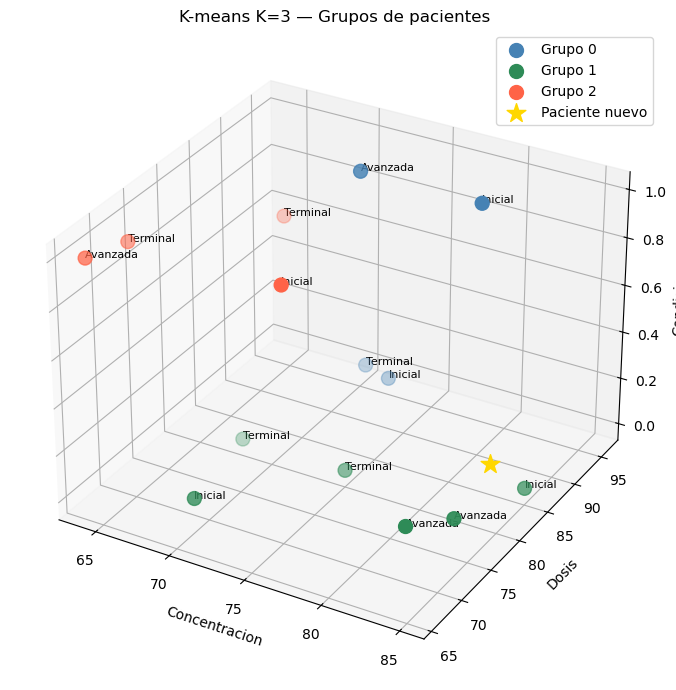

In [6]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

colores = {0: 'steelblue', 1: 'seagreen', 2: 'tomato'}

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for grupo, datos in df.groupby('Grupo'):
    ax.scatter(datos['Concentracion'], datos['Dosis'], datos['Condicion_enc'],
               color=colores[grupo], s=100, label=f'Grupo {grupo}', zorder=3)
    for _, fila in datos.iterrows():
        ax.text(fila['Concentracion'], fila['Dosis'], fila['Condicion_enc'],
                fila['Estado'], fontsize=8)

# Paciente nuevo
ax.scatter(82, 87, le.transform(['Debil'])[0],
           color='gold', s=200, marker='*', label='Paciente nuevo', zorder=5)

ax.set_xlabel('Concentracion')
ax.set_ylabel('Dosis')
ax.set_zlabel('Condicion')
ax.set_title('K-means K=3 — Grupos de pacientes')
ax.legend()
plt.tight_layout()
plt.show()

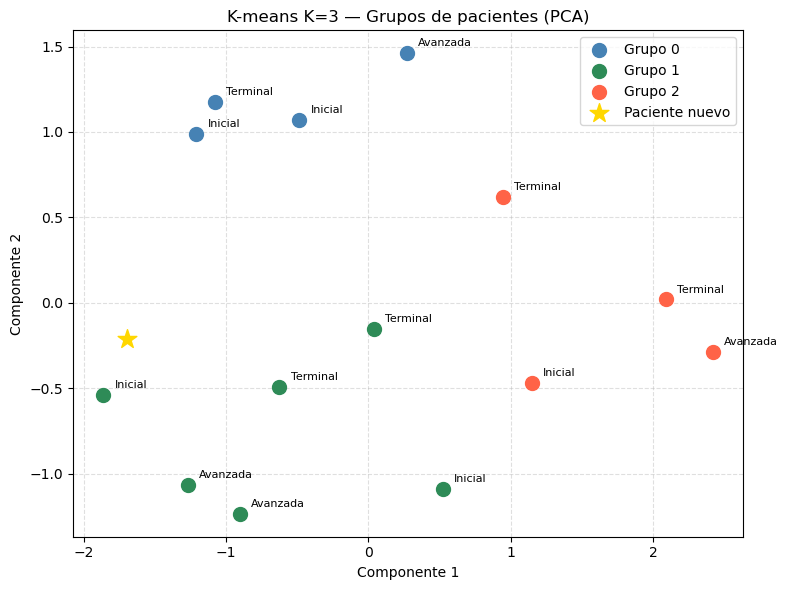

In [8]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Reducir a 2 dimensiones
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

colores = {0: 'steelblue', 1: 'seagreen', 2: 'tomato'}

fig, ax = plt.subplots(figsize=(8, 6))

for grupo in range(3):
    mask = df['Grupo'] == grupo
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               color=colores[grupo], s=100, label=f'Grupo {grupo}', zorder=3)
    for i, fila in df[mask].iterrows():
        ax.annotate(fila['Estado'], (X_pca[i, 0], X_pca[i, 1]),
                    textcoords='offset points', xytext=(8, 5), fontsize=8)

# Paciente nuevo
nuevo_pca = pca.transform(nuevo_scaled)
ax.scatter(nuevo_pca[0, 0], nuevo_pca[0, 1],
           color='gold', s=200, marker='*', label='Paciente nuevo', zorder=5)

ax.set_xlabel('Componente 1')
ax.set_ylabel('Componente 2')
ax.set_title('K-means K=3 — Grupos de pacientes (PCA)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()